### ** demand volatility**

**Objective:**  Segment SKUs and Regions based on demand stability to drive inventory allocation decisions.

**Metric:** Coefficient of Variation (CV) = Std Deviation / Mean.

**SQL FOcus:** Using SQL to oerform business logic claasification



Let us install **duckdb**

In [1]:
pip install duckdb

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import duckdb
import pandas as pd
import os

# Create a connection to an in-memory database
con = duckdb.connect(database=':memory:')

# "Register" our CSVs so DuckDB can see them as SQL tables
con.execute("CREATE VIEW demand_history AS SELECT * FROM read_csv_auto('../data/demand_history.csv')")
con.execute("CREATE VIEW products AS SELECT * FROM read_csv_auto('../data/products.csv')")

print("SQL Environment Ready. CSVs are now accessible as SQL tables!")

SQL Environment Ready. CSVs are now accessible as SQL tables!


**Now let us calculate the CV for every single SKU using SQL**

In [3]:
# Compute CV for every SKU across all weeks and regions combined
sku_cv = con.sql("""
    SELECT
        sku_id,
        ROUND(AVG(demand_units), 2)    AS avg_demand,
        ROUND(STDDEV(demand_units), 2) AS std_demand,
        ROUND(STDDEV(demand_units) / NULLIF(AVG(demand_units), 0), 4) AS cv
    FROM demand_history
    GROUP BY sku_id
    ORDER BY cv DESC
""").df()

display(sku_cv.head(10))

,sku_id,avg_demand,std_demand,cv
0,SKU_178,56.36,23.72,0.4208
1,SKU_236,39.64,16.68,0.4207
2,SKU_026,58.58,24.62,0.4202
3,SKU_201,32.08,13.33,0.4155
4,SKU_121,48.04,19.96,0.4155
5,SKU_004,23.49,9.65,0.4107
6,SKU_170,38.43,15.74,0.4095
7,SKU_062,44.23,18.04,0.4079
8,SKU_164,84.56,34.46,0.4076
9,SKU_165,41.69,16.89,0.4052


**Now let us puth these into buckets  - This will turn the numbers into behavior labels**

In [4]:
# Create the Classification rules
sku_cv['demand_class'] = pd.cut(
    sku_cv['cv'],
    bins=[0, 0.2, 0.5, 1.0, float('inf')],
    labels=['1_Very_Stable', '2_Moderately_Stable', '3_Volatile', '4_Extremely_Volatile']
)

# See how many SKUs fall into each bucket
summary = sku_cv['demand_class'].value_counts().sort_index()

print("--- Product Portfolio Volatility Summary ---")
print(summary)

--- Product Portfolio Volatility Summary ---
demand_class
1_Very_Stable            50
2_Moderately_Stable     250
3_Volatile                0
4_Extremely_Volatile      0
Name: count, dtype: int64


**As you can see, most of our products are not in the volatile region and most of them are in the Moderately stable - so to answer our question of this project where we asked: "What should we do when there is a volatility in supply chain?**

**Now we have to look for the top 10 most volatile SKUs**

In [ ]:
# Top 10 SKUs closest to the volatile threshold
top_volatile = sku_cv.nlargest(10, 'cv')[['sku_id', 'avg_demand', 'std_demand', 'cv', 'demand_class']]

print("--- Top 10 closest to the Volatile Threshold (Highest CV) ---")
display(top_volatile)

--- Top 10 closest to the Volatile Threshold (Highest CV) ---


,sku_id,avg_demand,std_demand,cv,demand_class
0,SKU_178,56.36,23.72,0.4208,2_Moderately_Stable
1,SKU_236,39.64,16.68,0.4207,2_Moderately_Stable
2,SKU_026,58.58,24.62,0.4202,2_Moderately_Stable
3,SKU_201,32.08,13.33,0.4155,2_Moderately_Stable
4,SKU_121,48.04,19.96,0.4155,2_Moderately_Stable
5,SKU_004,23.49,9.65,0.4107,2_Moderately_Stable
6,SKU_170,38.43,15.74,0.4095,2_Moderately_Stable
7,SKU_062,44.23,18.04,0.4079,2_Moderately_Stable
8,SKU_164,84.56,34.46,0.4076,2_Moderately_Stable
9,SKU_165,41.69,16.89,0.4052,2_Moderately_Stable


**Now let us look at the opposite  - Top 10 most stable SKUs**

In [ ]:
#top 10 SKUs with the lowest CV (most stable)
top_stable = sku_cv.nsmallest(10, 'cv')[['sku_id', 'avg_demand', 'std_demand', 'cv', 'demand_class']]

print("--- Top 10 Most Stable SKUs (Lowest CV) ---")
display(top_stable)

--- Top 10 Most Stable SKUs (Lowest CV) ---


,sku_id,avg_demand,std_demand,cv,demand_class
299,SKU_292,132.44,23.53,0.1777,1_Very_Stable
298,SKU_204,68.68,12.46,0.1814,1_Very_Stable
297,SKU_091,102.25,18.61,0.1820,1_Very_Stable
295,SKU_259,93.98,17.20,0.1830,1_Very_Stable
296,SKU_070,124.93,22.86,0.1830,1_Very_Stable
294,SKU_159,129.78,23.81,0.1835,1_Very_Stable
293,SKU_016,139.95,25.71,0.1837,1_Very_Stable
292,SKU_030,206.01,38.16,0.1852,1_Very_Stable
291,SKU_285,170.92,31.75,0.1858,1_Very_Stable
289,SKU_050,57.44,10.71,0.1865,1_Very_Stable


**As you can see here, the most stables SKUs also have a very high demand - triple digits.**

**Finding 1**


**The portfolio exhibits low overall demand uncertainty**.

    100% of SKUs are Stable or Moderately Stable.
    No SKU is classified as Volatile or Extremely Volatile.


**Finding 2**


The gap between the most stable and least stable products is relatively small.

**Lowest CV: 0.1777**
**Highest CV: 0.4208**
**This suggests demand behavior is consistent across the catalog.**

**Finding 3**

Several high-volume SKUs are also among the most stable.

This makes them attractive candidates for aggressive inventory allocation

**Now lwt us visualize the portfolio CV Distribution**

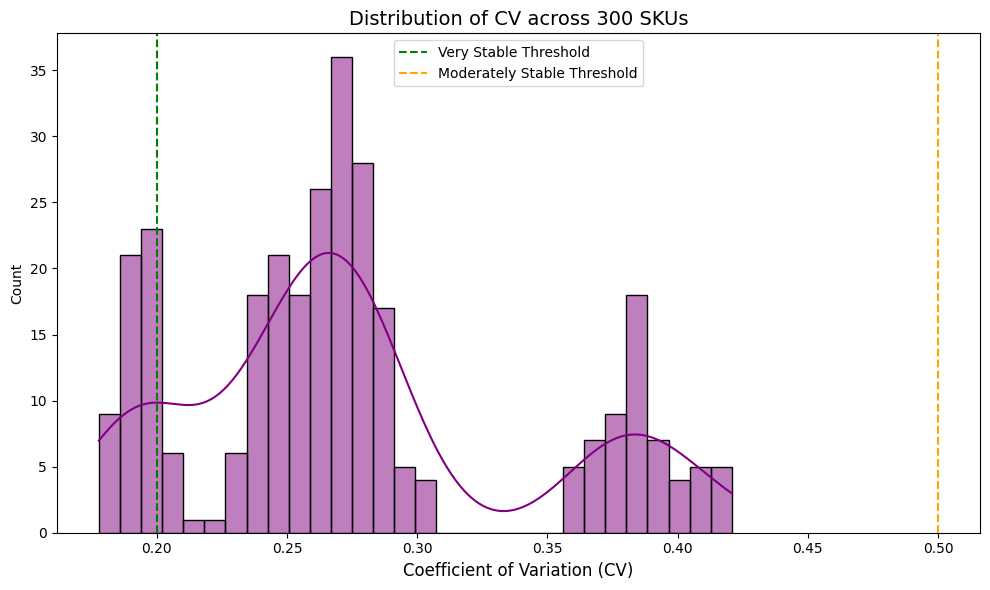

Chart saved.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(sku_cv['cv'], bins=30, kde=True, color='purple')
plt.axvline(0.2, color='green', linestyle='--', label='Very Stable Threshold')
plt.axvline(0.5, color='orange', linestyle='--', label='Moderately Stable Threshold')
plt.title('Distribution of CV across 300 SKUs', fontsize=14)
plt.xlabel('Coefficient of Variation (CV)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/charts/02_sku_cv_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Chart saved.")

### **Notebook 02 Conclusion: The Verdict**
* **Portfolio Risk:** Low. 100% of SKUs are classified as Stable or Moderately Stable.
* **Predictability:** High. With CVs maxing out at 0.42, a standard forecasting model should perform well.
* **The "DI Shift":** Since product demand is stable, our supply chain "stress" must be coming from **geography (regions)** or **external shocks**.
* **Next Action:** Move to **Notebook 03: Region Volatility** to find out which warehouse is the "eye of the storm."

Now let us visualize the **Top 15 volatile SKUs**